In [144]:
# Import libraries
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [145]:
# Load the dataset
df= pd.read_csv("GlobalLandTemperaturesByCountry.csv")
df['dt']= pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year
0,1743-11-01,4.384,2.294,Åland,1743
1,1743-12-01,NaN,NaN,Åland,1743
2,1744-01-01,NaN,NaN,Åland,1744
3,1744-02-01,NaN,NaN,Åland,1744
4,1744-03-01,NaN,NaN,Åland,1744
...,...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe,2013
577458,2013-06-01,17.613,0.473,Zimbabwe,2013
577459,2013-07-01,17.000,0.453,Zimbabwe,2013
577460,2013-08-01,19.759,0.717,Zimbabwe,2013


In [146]:
# Drop missing values
df.isnull().any()
df = df.dropna(subset=["AverageTemperature", "Country"])

In [147]:
# Filtrer from ... (you can change this year)
df =df[df['Year'] >= 1900]

In [148]:
# Group to get average annual temperature per country

df_temp = df.groupby(['Country', 'Year'])['AverageTemperature'].mean().reset_index()

df_temp

,Country,Year,AverageTemperature
0,Afghanistan,1900,13.749333
1,Afghanistan,1901,13.894000
2,Afghanistan,1902,14.505833
3,Afghanistan,1903,12.986417
4,Afghanistan,1904,13.805750
...,...,...,...
27480,Åland,2009,6.489083
27481,Åland,2010,4.861917
27482,Åland,2011,7.170750
27483,Åland,2012,6.063917


In [149]:
# Save
df_temp.to_csv("Global_Temp_Country_final.csv", index=False)

In [150]:
# Show all statistics
print(df_temp.shape)
print(df_temp.describe(include="all"))

(27485, 3)
            Country          Year  AverageTemperature
count         27485  27485.000000        27485.000000
unique          242           NaN                 NaN
top     Afghanistan           NaN                 NaN
freq            114           NaN                 NaN
mean            NaN   1956.629434           18.834653
std             NaN     32.889737            9.109993
min             NaN   1900.000000          -20.446833
25%             NaN   1928.000000           10.942250
50%             NaN   1957.000000           22.885750
75%             NaN   1985.000000           26.235083
max             NaN   2013.000000           30.744750


In [151]:
# Separate target variable Y from features X
print("Separating target variable from features...")

# Choose the columns you want to have as your features
features_list = ["Country", "Year"]

X = df_temp.loc[:,features_list] # We add feature_list into our loc 
y = df_temp.loc[:,"AverageTemperature"] # We set "Profit" as the target variable

print("...Done.")
print()

Separating target variable from features...
...Done.



In [152]:
# Split into train and test sets
print("Splitting dataset into train set and test set...")
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=0)
print("...Done.")

Splitting dataset into train set and test set...
...Done.


In [153]:
### Training pipeline
print("--- Training pipeline ---")
print("#### X_train BEFORE preprocessing ####")
print(X_train.head(), "")

# Preprocessing
print("Encoding categorical features and standardizing numerical features...")

numeric_features = [1]  # 'Year'
numeric_transformer = StandardScaler()

categorical_features = [0]  # 'Country'
categorical_transformer = OneHotEncoder()

feature_encoder = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ])

X_train_encoded = feature_encoder.fit_transform(X_train)
print("...Done.")
print("#### X_train AFTER preprocessing ####")
print(X_train_encoded[0:5, :], )



--- Training pipeline ---
#### X_train BEFORE preprocessing ####
            Country  Year
4046        Burundi  1956
10117    Guadeloupe  1920
14924    Madagascar  1990
3866   Burkina Faso  2004
10644        Guinea  1994 
Encoding categorical features and standardizing numerical features...
...Done.
#### X_train AFTER preprocessing ####
  (0, 35)	1.0
  (0, 242)	-0.017868960218188214
  (1, 89)	1.0
  (1, 242)	-1.1157032587271407
  (2, 131)	1.0
  (2, 242)	1.0189745439291558
  (3, 33)	1.0
  (3, 242)	1.4459101044604152
  (4, 93)	1.0
  (4, 242)	1.1409561326523727


In [154]:
# Train model
print("Train model...")
regressor = LinearRegression()
regressor.fit(X_train_encoded, y_train)
print("...Done.")


Train model...
...Done.


In [155]:

# Predictions on training set
print("Predictions on training set...")
y_train_pred = regressor.predict(X_train_encoded)
print(y_train_pred[:5], )


Predictions on training set...
[20.2078447  26.15387316 23.23106222 28.7796467  26.04336119]


In [156]:
### Testing pipeline
print("--- Testing pipeline ---")
print("Standardizing numerical features...")
print(X_test.head(), )

X_test_encoded = feature_encoder.transform(X_test)
print("...Done.")
print(X_test_encoded[:5], )



--- Testing pipeline ---
Standardizing numerical features...
                              Country  Year
15331                           Malta  1941
21799                          Serbia  1914
18789                           Palau  1982
8220   Federated States Of Micronesia  1913
5243                 Christmas Island  2013
...Done.
  (0, 135)	1.0
  (0, 242)	-0.4752999179302518
  (1, 192)	1.0
  (1, 242)	-1.2986756418119663
  (2, 165)	1.0
  (2, 242)	0.775011366482722
  (3, 72)	1.0
  (3, 242)	-1.3291710389927704
  (4, 45)	1.0
  (4, 242)	1.7203686790876533


In [157]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = regressor.predict(X_test_encoded)
print(y_test_pred[:5], )


Predictions on test set...
[18.67118656  9.85080422 27.5737205  26.48581818 26.55732983]


In [158]:
### Model evaluation
print("--- Assessing the performances of the model ---")
print("R2 score on training set : ", regressor.score(X_train_encoded, y_train))
print("R2 score on test set : ", regressor.score(X_test_encoded, y_test))
print("Coefficients are: ", regressor.coef_[:5])
print("Intercept is: ", regressor.intercept_, )


--- Assessing the performances of the model ---
R2 score on training set :  0.997658606857399
R2 score on test set :  0.9974066560127434
Coefficients are:  [-4.51831389  5.44119802 -5.89280249  4.47722673  7.9396188 ]
Intercept is:  18.784093109120043


In [159]:

# Access transformed column names
print("All transformers are: ", feature_encoder.transformers_)
print("One Hot Encoder transformer is: ", feature_encoder.transformers_[0][1])

categorical_column_names = feature_encoder.transformers_[0][1].get_feature_names_out(['Country'])
numerical_column_names = ['Year']
all_column_names = np.append(categorical_column_names, numerical_column_names)


All transformers are:  [('cat', OneHotEncoder(), [0]), ('num', StandardScaler(), [1])]
One Hot Encoder transformer is:  OneHotEncoder()


In [160]:

# Feature importance
feature_importance = pd.DataFrame({
    "feature_names": all_column_names,
    "coefficients": np.abs(regressor.coef_)
}).sort_values(by="coefficients", ascending=False)

print("Top features:")
print(feature_importance.head(10))



Top features:
                                         feature_names  coefficients
87                                   Country_Greenland     36.965815
57                                     Country_Denmark     36.390478
209                     Country_Svalbard And Jan Mayen     25.830037
179                                     Country_Russia     23.939600
38                                      Country_Canada     23.497866
143                                   Country_Mongolia     19.222530
161                                     Country_Norway     18.290550
203  Country_South Georgia And The South Sandwich Isla     17.338985
74                                     Country_Finland     17.120915
101                                    Country_Iceland     17.031567


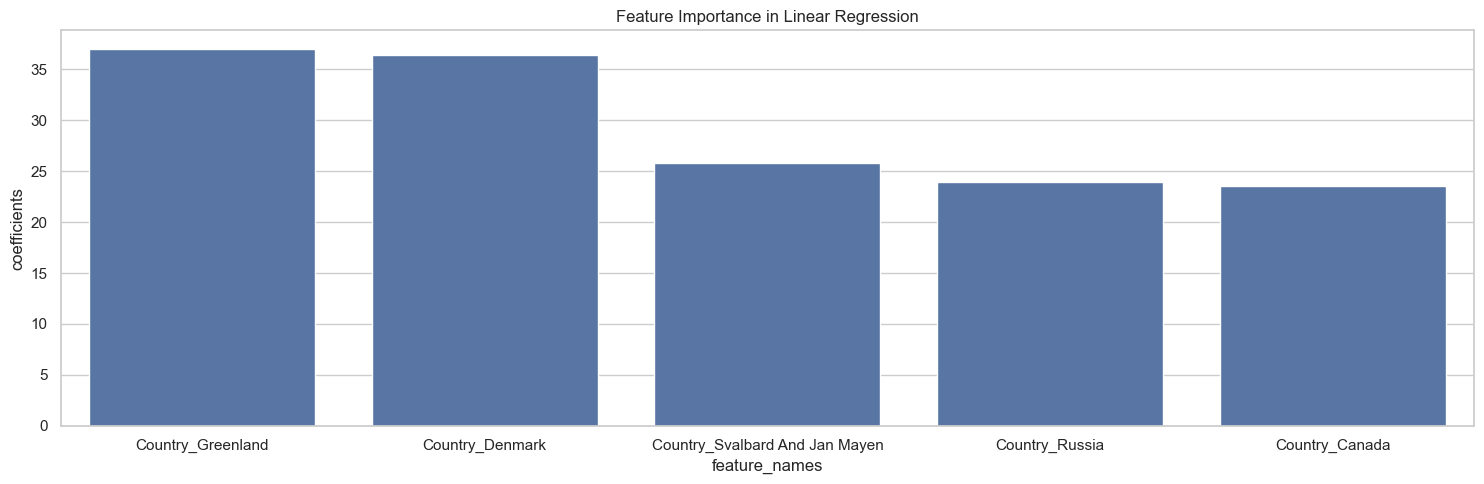

In [161]:

# Visualization
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))
sns.barplot(x="feature_names", 
            y="coefficients", 
            data=feature_importance.head(5))
plt.title("Feature Importance in Linear Regression")
plt.tight_layout()
plt.show()